# lut_8bit_tanh

## 1. Write bitstream

In [30]:
from pynq import Overlay

overlay = Overlay("./lut_8bit_tanh.bit")

## 2. Create GPIOs API

In [31]:
from pynq import MMIO

axi_gpio_0_addr = 0x41200000
axi_gpio_1_addr = 0x41210000
axi_gpio_range = 0x10000
gpio_input_a = MMIO(axi_gpio_0_addr, axi_gpio_range)
gpio_result = MMIO(axi_gpio_1_addr, axi_gpio_range)

data_width, x_min, x_max, y_min, y_max = 8, 0, 1, 0, 1
x_step = (x_max - x_min) / (2 ** data_width)
y_step = (x_max - x_min) / (2 ** data_width)

def write_input_a(value):
    gpio_input_a.write(0x0, int(value / x_step))
def read_result():
    return gpio_result.read(0x0) * y_step

## 3. Play with it!

In [40]:
import math
import numpy as np

x_values = np.arange(0, 1, 0.001)
y_theoretical = []
y_evaluator = []
absolute_error = []

for x_value in x_values:
    theoretical = (1+math.tanh(4*(2*x_value-1)))/2
    evaluator = read_result()
    y_theoretical.append(theoretical)
    write_input_a(x_value)
    y_evaluator.append(evaluator)
    absolute_error.append(abs(theoretical - evaluator))

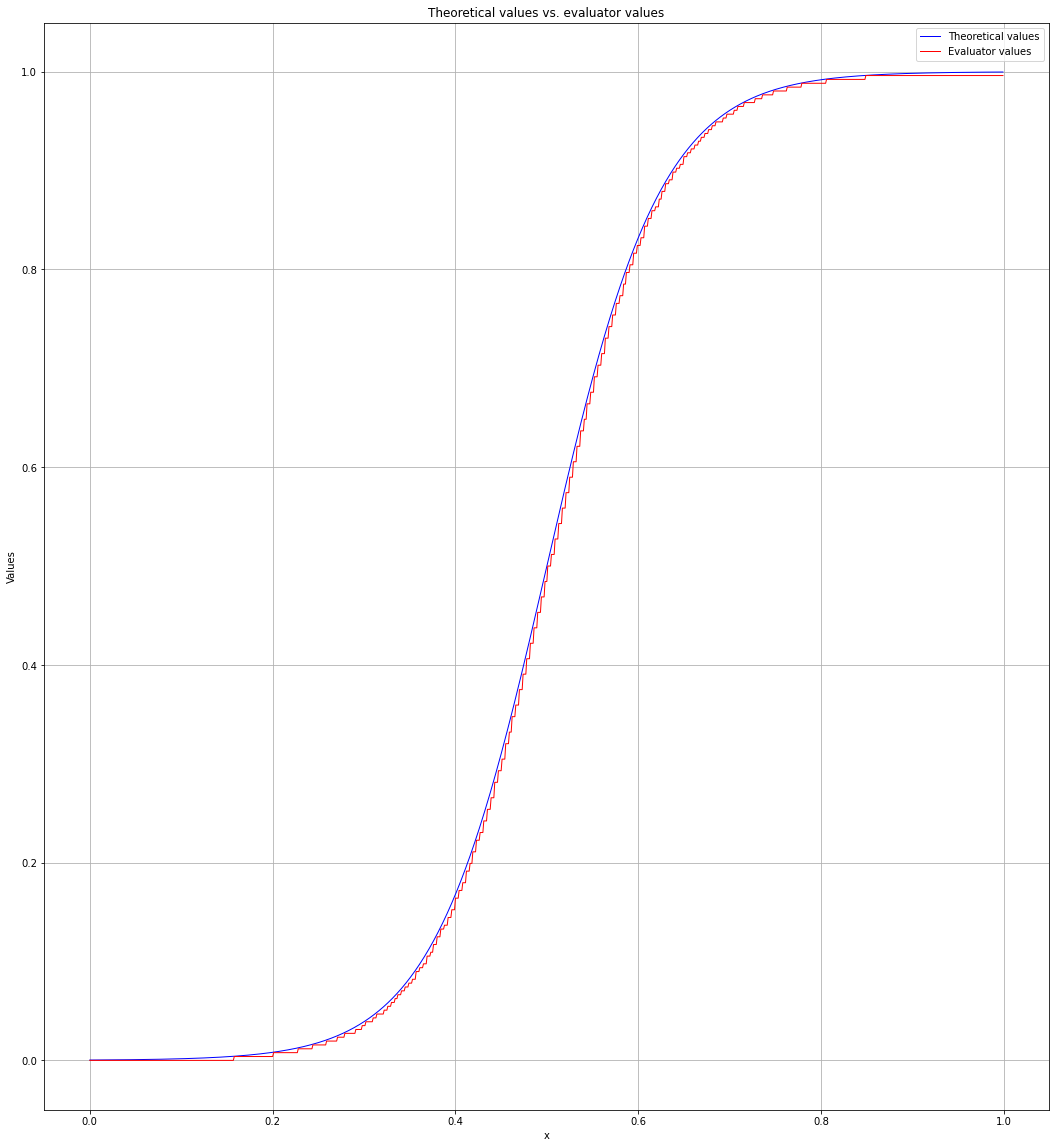

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 20))
plt.plot(x_values, y_theoretical, color='blue', linewidth=1, label='Theoretical values')
plt.plot(x_values, y_evaluator, color='red', linewidth=1, label='Evaluator values')
plt.title('Theoretical values vs. evaluator values')
plt.xlabel('x')
plt.ylabel('Values')
plt.grid(True)
plt.legend()
plt.show()

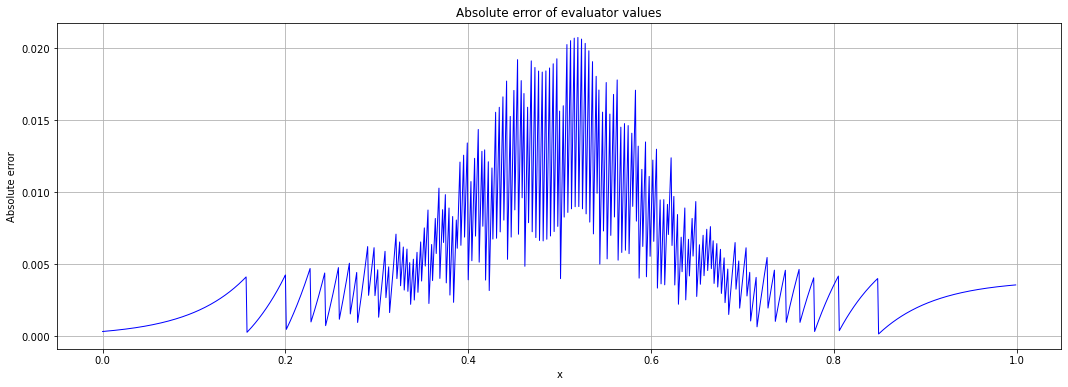

In [43]:
plt.figure(figsize=(18, 6))
plt.plot(x_values, absolute_error, color='blue', linewidth=1)
plt.title('Absolute error of evaluator values')
plt.xlabel('x')
plt.ylabel('Absolute error')
plt.grid(True)
plt.show()